In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

In [36]:
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

df_plot = df[['Marital_Status'] + mnt_cols].dropna().copy()
df_plot['Total_Mnt'] = df_plot[mnt_cols].sum(axis=1)

## Ticket medio por estado civil

C:\Users\Caju\AppData\Local\Temp\ipykernel_1792\3080055377.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='Marital_Status', y='Total_Mnt', order=marital_order,


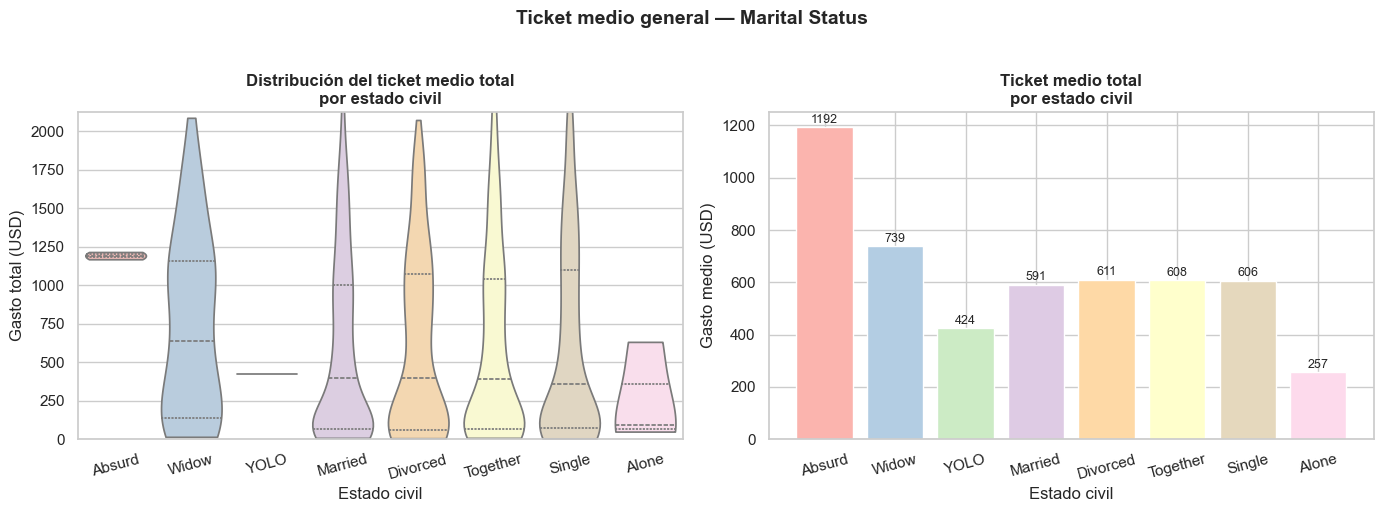

In [37]:
marital_order = df_plot.groupby('Marital_Status')['Total_Mnt'].median().sort_values(ascending=False).index.tolist()
marital_palette = sns.color_palette('Pastel1', n_colors=len(marital_order))
y_max = np.percentile(df_plot['Total_Mnt'], 95) * 1.2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin
sns.violinplot(data=df_plot, x='Marital_Status', y='Total_Mnt', order=marital_order,
               palette=marital_palette, inner='quartile', cut=0, ax=axes[0])
axes[0].set_ylim(0, y_max)
axes[0].set_title('Distribución del ticket medio total\npor estado civil', fontweight='bold')
axes[0].set_xlabel('Estado civil')
axes[0].set_ylabel('Gasto total (USD)')
axes[0].tick_params(axis='x', rotation=15)

# Barras
mean_marital = df_plot.groupby('Marital_Status')['Total_Mnt'].mean().reindex(marital_order)
bars = axes[1].bar(mean_marital.index, mean_marital.values, color=marital_palette)
for bar, val in zip(bars, mean_marital.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 5, f'{val:.0f}',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_title('Ticket medio total\npor estado civil', fontweight='bold')
axes[1].set_xlabel('Estado civil')
axes[1].set_ylabel('Gasto medio (USD)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Ticket medio general — Marital Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Caju\AppData\Local\Temp\ipykernel_1792\2917204634.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='Marital_Status', y=col, order=marital_order,
C:\Users\Caju\AppData\Local\Temp\ipykernel_1792\2917204634.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='Marital_Status', y=col, order=marital_order,
C:\Users\Caju\AppData\Local\Temp\ipykernel_1792\2917204634.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='Marital_Status', y=col, order=marital_order,
C:\Users\Caju\AppDa

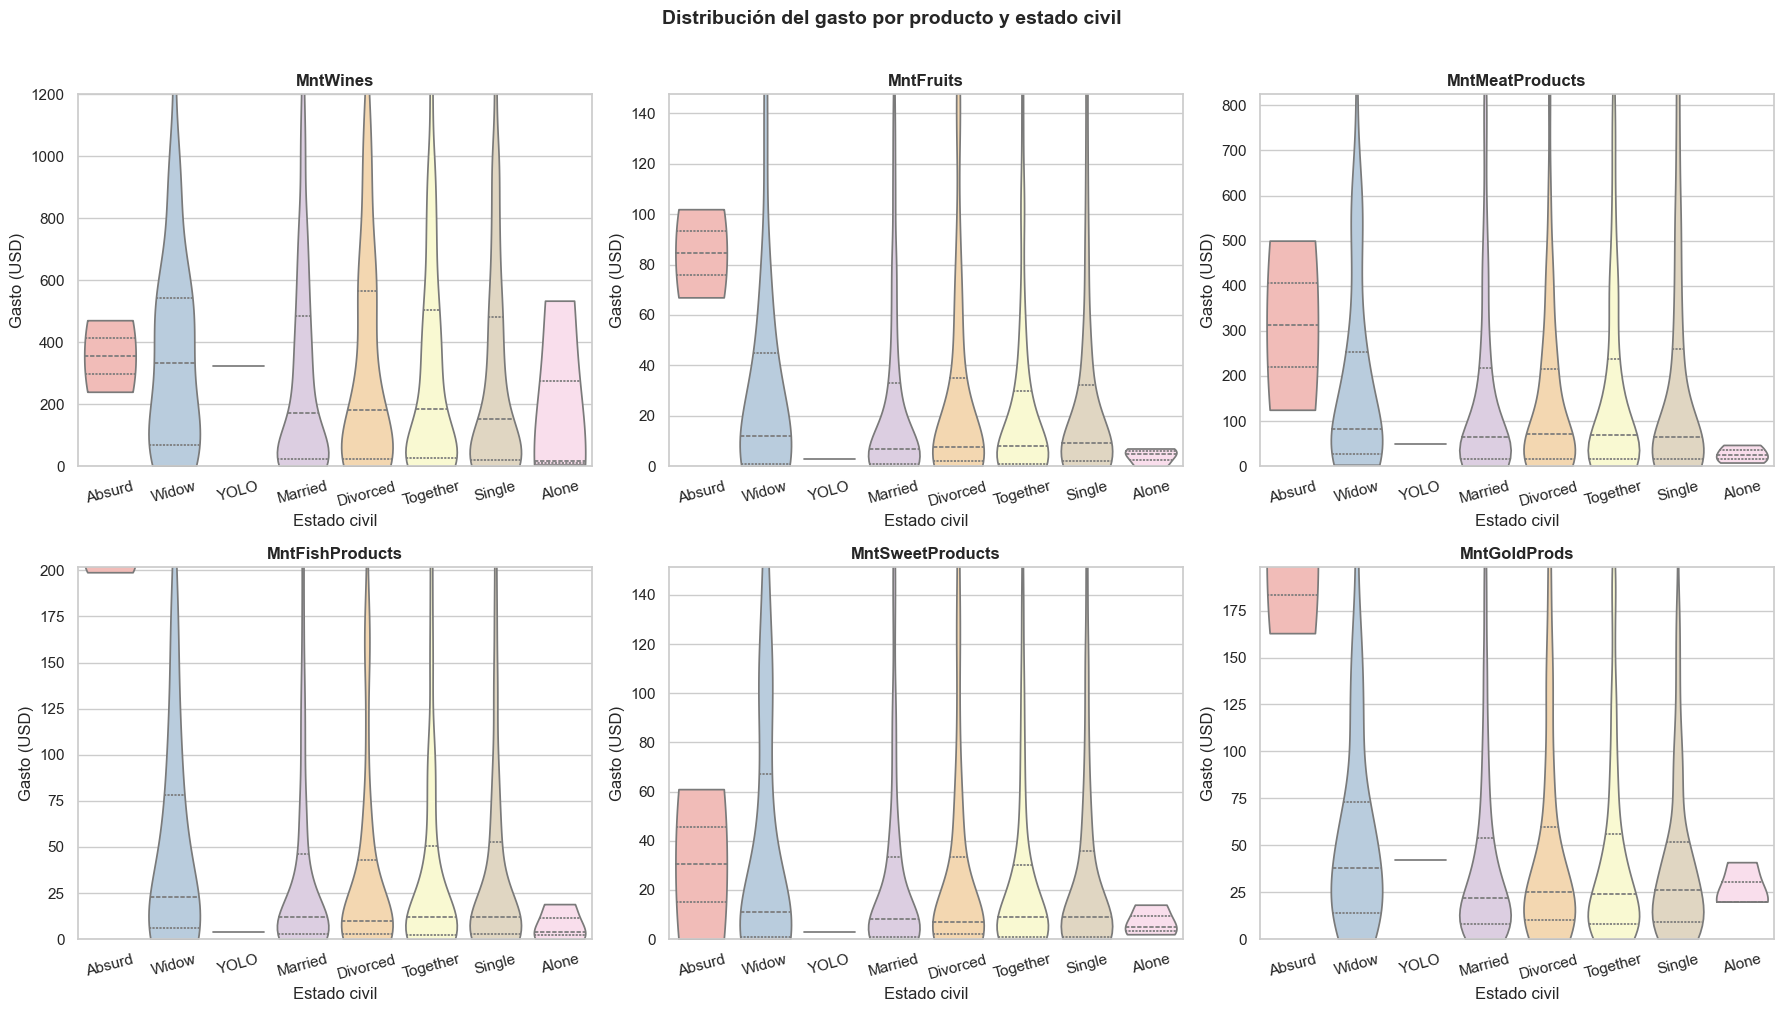

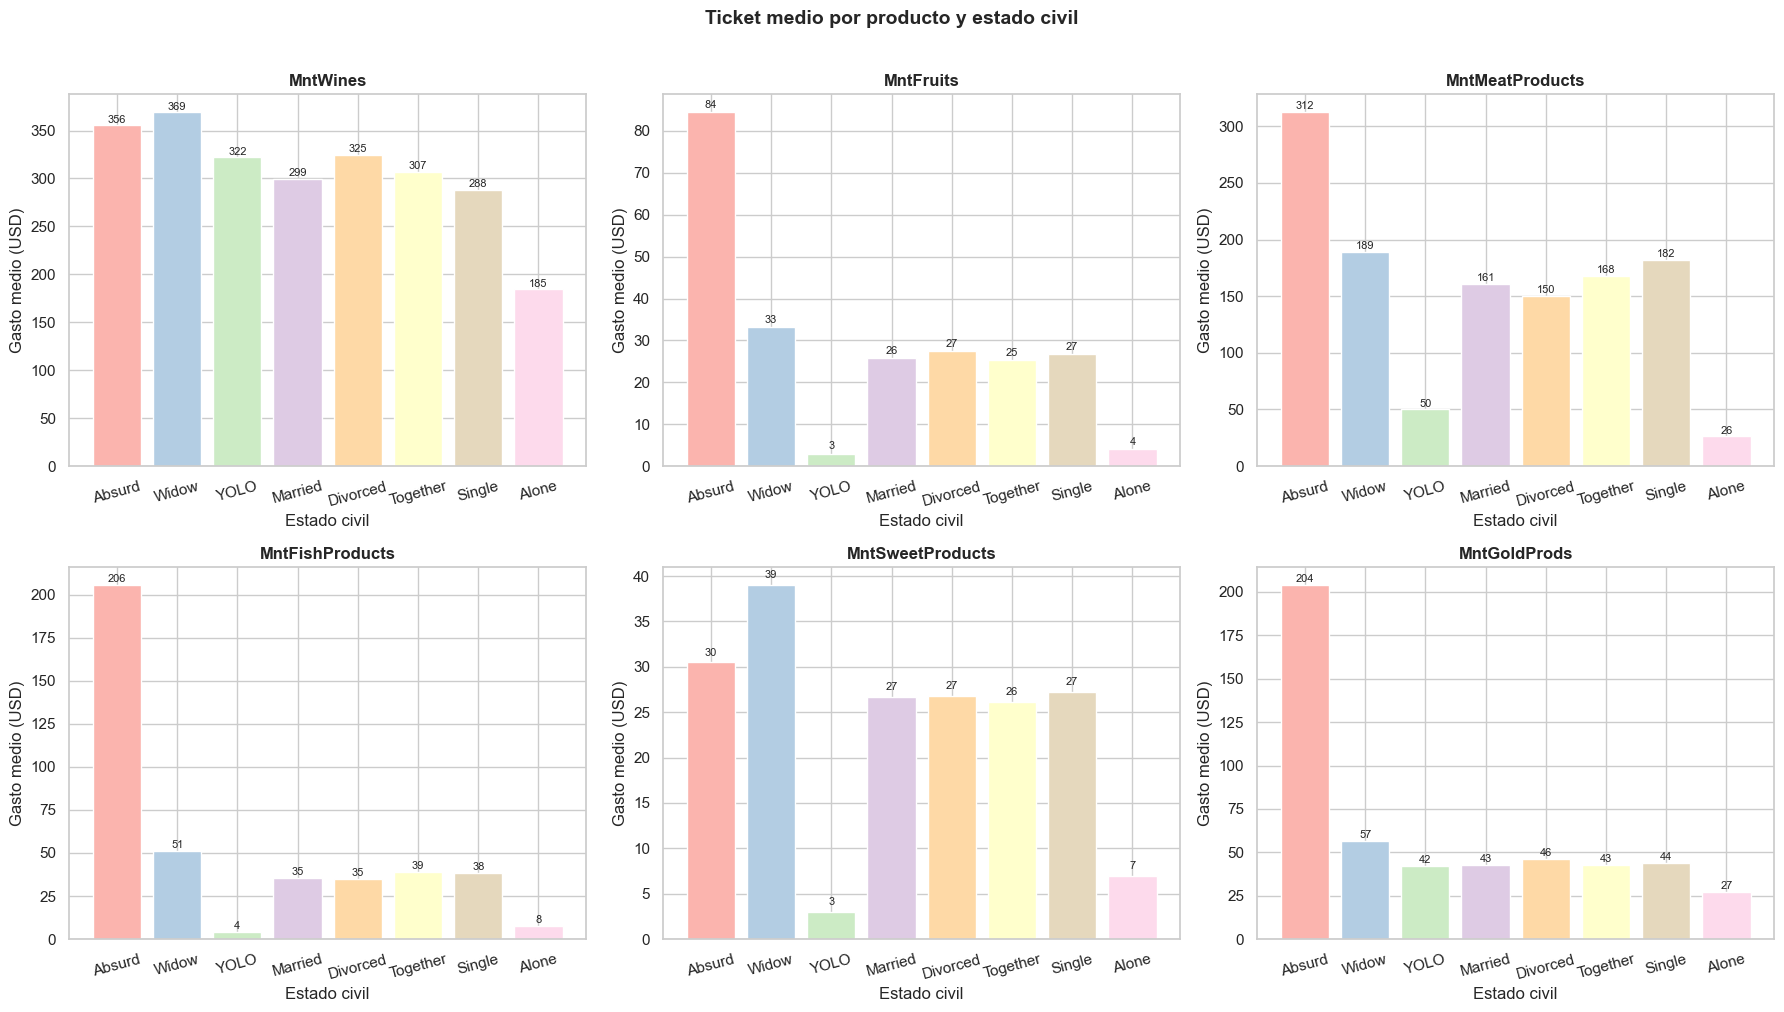

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, mnt_cols):
    y_max_col = np.percentile(df_plot[col], 95) * 1.2
    sns.violinplot(data=df_plot, x='Marital_Status', y=col, order=marital_order,
                   palette=marital_palette, inner='quartile', cut=0, ax=ax)
    ax.set_ylim(0, y_max_col)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Estado civil')
    ax.set_ylabel('Gasto (USD)')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Distribución del gasto por producto y estado civil', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Barras por producto
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, mnt_cols):
    mean_col = df_plot.groupby('Marital_Status')[col].mean().reindex(marital_order)
    bars = ax.bar(mean_col.index, mean_col.values, color=marital_palette)
    for bar, val in zip(bars, mean_col.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5, f'{val:.0f}',
                ha='center', va='bottom', fontsize=8)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Estado civil')
    ax.set_ylabel('Gasto medio (USD)')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Ticket medio por producto y estado civil', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Estos graficos tienen ruido de variables que no tienen sentido voy a eliminarlas para poder ver los datos más claramente.

## Ticket medio por estado civil (excluyendo Absurd, Alone y YOLO)

C:\Users\Caju\AppData\Local\Temp\ipykernel_1792\341573631.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='Marital_Status', y='Total_Mnt', order=marital_order_clean,


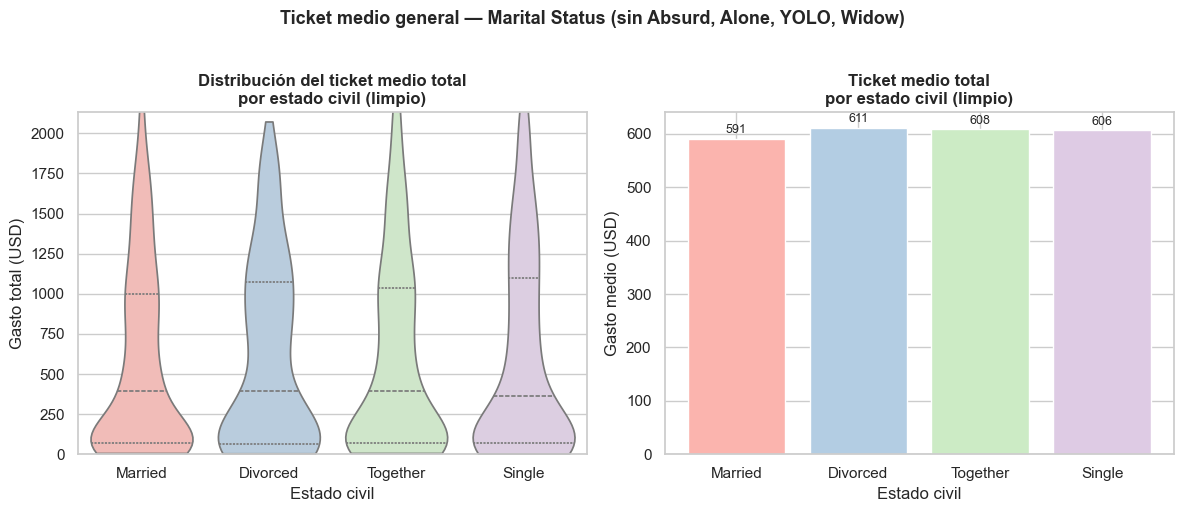

C:\Users\Caju\AppData\Local\Temp\ipykernel_1792\341573631.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='Marital_Status', y=col, order=marital_order_clean,
C:\Users\Caju\AppData\Local\Temp\ipykernel_1792\341573631.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='Marital_Status', y=col, order=marital_order_clean,
C:\Users\Caju\AppData\Local\Temp\ipykernel_1792\341573631.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='Marital_Status', y=col, order=marital_order_clean

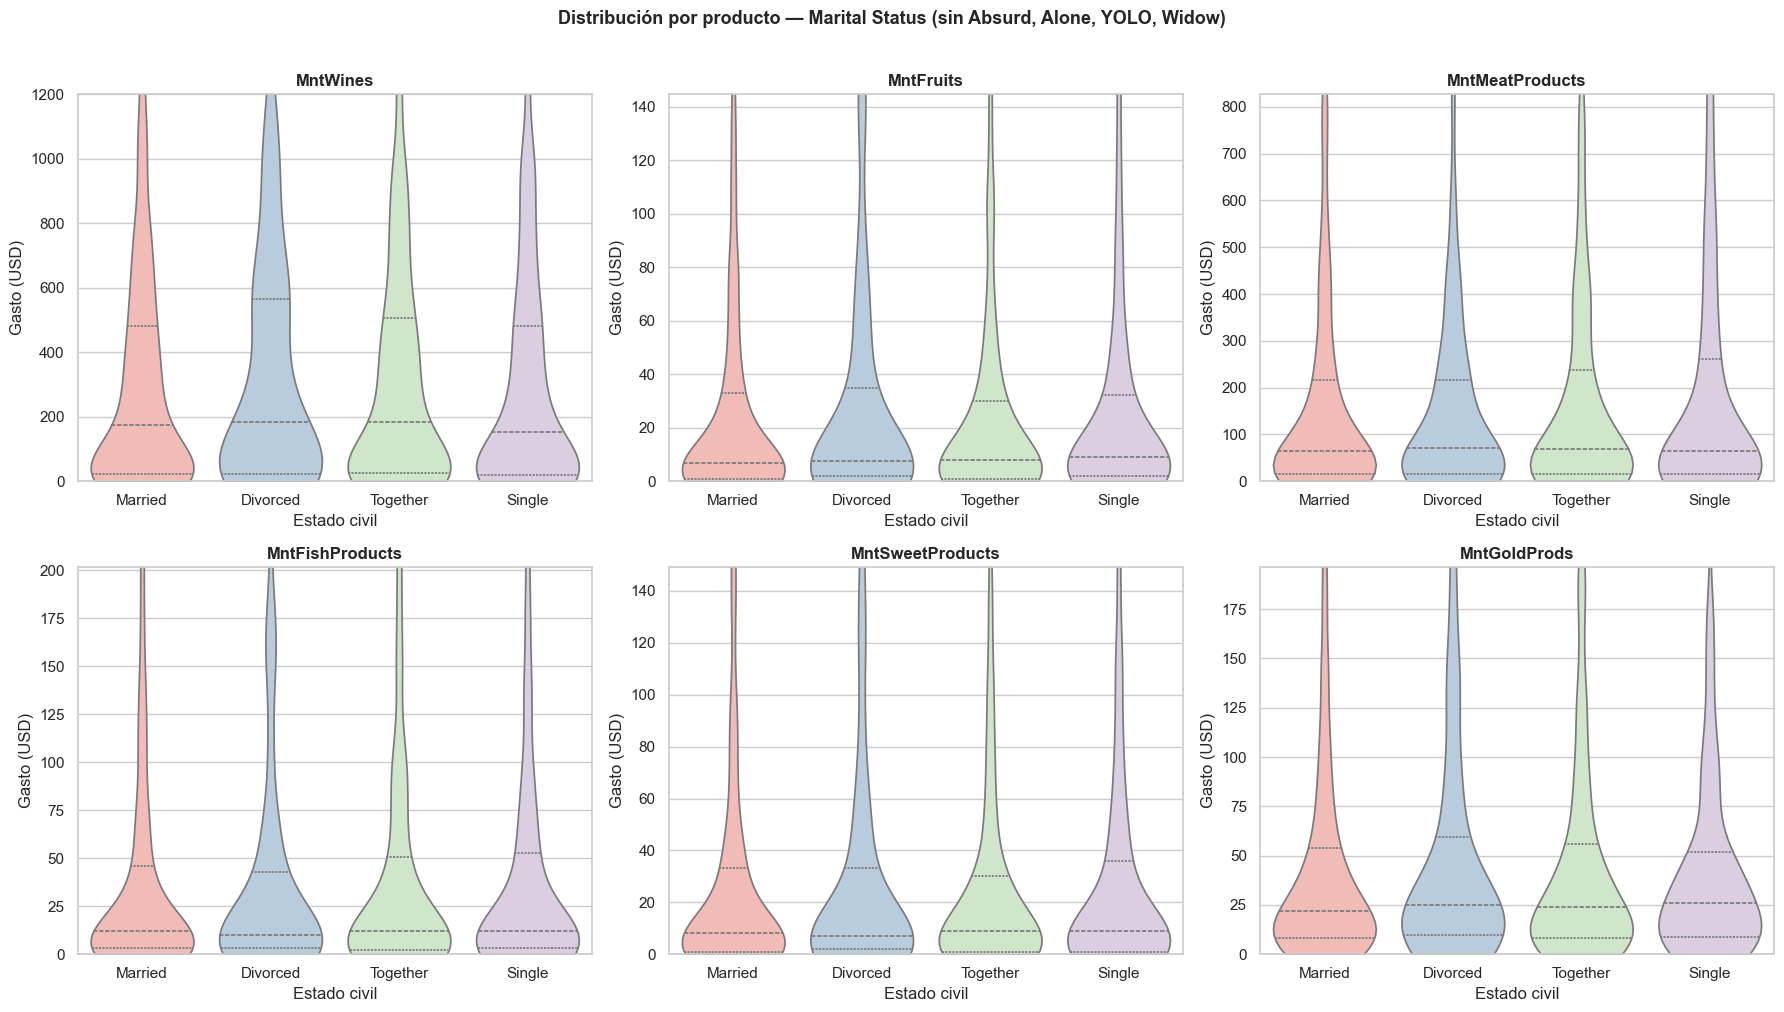

In [39]:
exclude = ['Absurd', 'Alone', 'YOLO', 'Widow']
df_clean = df_plot[~df_plot['Marital_Status'].isin(exclude)].copy()

marital_order_clean = df_clean.groupby('Marital_Status')['Total_Mnt'].median().sort_values(ascending=False).index.tolist()
marital_palette_clean = sns.color_palette('Pastel1', n_colors=len(marital_order_clean))
y_max_clean = np.percentile(df_clean['Total_Mnt'], 95) * 1.2

# --- Ticket medio total ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.violinplot(data=df_clean, x='Marital_Status', y='Total_Mnt', order=marital_order_clean,
               palette=marital_palette_clean, inner='quartile', cut=0, ax=axes[0])
axes[0].set_ylim(0, y_max_clean)
axes[0].set_title('Distribución del ticket medio total\npor estado civil (limpio)', fontweight='bold')
axes[0].set_xlabel('Estado civil')
axes[0].set_ylabel('Gasto total (USD)')

mean_clean = df_clean.groupby('Marital_Status')['Total_Mnt'].mean().reindex(marital_order_clean)
bars = axes[1].bar(mean_clean.index, mean_clean.values, color=marital_palette_clean)
for bar, val in zip(bars, mean_clean.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 5, f'{val:.0f}',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_title('Ticket medio total\npor estado civil (limpio)', fontweight='bold')
axes[1].set_xlabel('Estado civil')
axes[1].set_ylabel('Gasto medio (USD)')

plt.suptitle('Ticket medio general — Marital Status (sin Absurd, Alone, YOLO, Widow)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Por producto ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, mnt_cols):
    y_max_col = np.percentile(df_clean[col], 95) * 1.2
    sns.violinplot(data=df_clean, x='Marital_Status', y=col, order=marital_order_clean,
                   palette=marital_palette_clean, inner='quartile', cut=0, ax=ax)
    ax.set_ylim(0, y_max_col)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Estado civil')
    ax.set_ylabel('Gasto (USD)')

plt.suptitle('Distribución por producto — Marital Status (sin Absurd, Alone, YOLO, Widow)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Mi conclusión es que no existen diferencias que sean relevantes a la hora de consumir vino en base al estado relacional de la persona.

He querido ver si era asi en otros productos pero las distribuciones son muy similares en todos. No parece que valla a ser un  buen perdictor.

Con el numero de datos que hay pienso que la diferencia entre variables puede deberse al azar y habiendo visto en el ejercicio 1 las correlaciones, siendo esta muy baja no seguiria indagando por aquí. 